<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P5_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #5 :** *Tipos de traslación de imágenes*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. TRANSFORMACIONES GEOMETRICAS**


***Instrucciones:*** Realiza las transformaciones geométricas a las imágenes médicas.

### **EJERCICIO 1.** ***Traslación básica de imagen.***

Primeramente, para modificar geométricamente la imagen debemos seleccionar la imagen a utilizar. En este caso, escogimos una imagen médica, más específicamente una Resonancia Magnética del Cerebro en un plano sagital, en donde esta ya se encuentra en escala de grises.

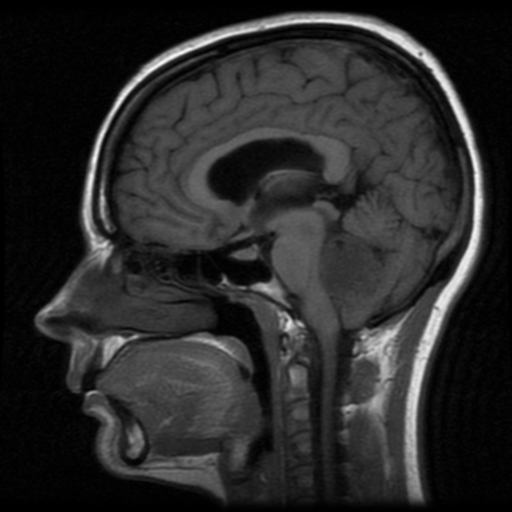

Para la elaboración del código, utilizaremos ciertas librerías que nos facilitaran la lectura, procesamiento y visualización de las imágenes. Emplearemos OpenCV, Numpy y Matplotlib.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Después, cargamos la imagen utilizando OpenCV en Python mediante ***cv2.imread(“RMcerebral.jpg”)***.  Utilizaremos la función ***.shape*** para poder obtener las dimensiones de la imagen, lo cual utilizaremos más adelante. Indicamos su lectura como imagen en escala de grises.


In [ ]:
RMcerebral = cv2.imread("RMcerebral.jpg", cv2.IMREAD_GRAYSCALE)
alto, ancho = RMcerebral.shape[:2]

Posteriormente, aplicaremos la traslación básica en la imagen, en donde, desplazaremos 50 píxeles en el eje horizontal (x) y 30 píxeles en el eje vertical (y). La modificación geométrica de traslación nos permite mover todos los píxeles de la imagen a una nueva posición definida sin alterar ni su tamaño.

In [ ]:
# TRASLACION BASICA CON X = 50 y Y = 30
# tx = derecha/izq, ty = abajo/arriba
tx1 = 50
ty1 = 30

M1_traslacion = np.float32([[1, 0, tx1], [0, 1, ty1]]) # matriz de traslacion
imagen_traslacionent = cv2.warpAffine(RMcerebral, M1_traslacion, (ancho, alto))

En el código presentamos lo que se conoce como *“Matriz de traslación”*, la cual, nos permite representar la modificación de la imagen sin alterar la forma ni el tamaño de la imagen original. Definimos valores unitarios ( 1 ) en la diagonal para no permitir cambios en la escala y que solo estos se realicen en los ejes x y y (tx y ty).

Utilizamos la función ***cv2.warpAffine*** que se utiliza para aplicar transformaciones geométricas a una imagen a partir de una matriz de transformación. Las dimensiones obtenidas por el ***.shape*** se utilizan directamente en esta función, especificando  el tamaño de la imagen de salida mediante los parámetros *(alto, ancho)*. Esto asegura que la imagen transformada conserve las mismas dimensiones que la imagen original, evitando deformaciones.

Ahora, visualizando la imagen con modificación geométrica de traslación básica:


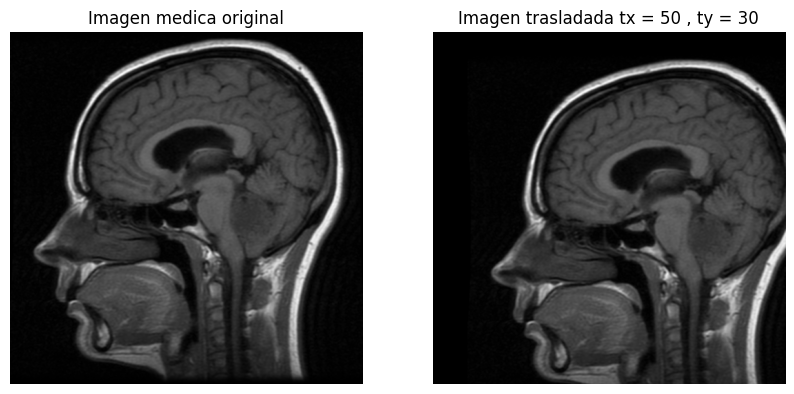

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.imshow(RMcerebral, cmap="gray")
plt.title("Imagen medica original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_traslacionent, cmap="gray")
plt.title("Imagen trasladada tx = 50 , ty = 30")
plt.axis("off")

plt.show()

### **EJERCICIO 2.** ***Traslación con valores decimales.***

Para este segundo ejercicio utilizaremos de igual manera la imagen médica de Resonancia Magnética del Cerebro en un plano sagital en escala de grises ya determinada y utilizada en el ***Ejercicio 1***.

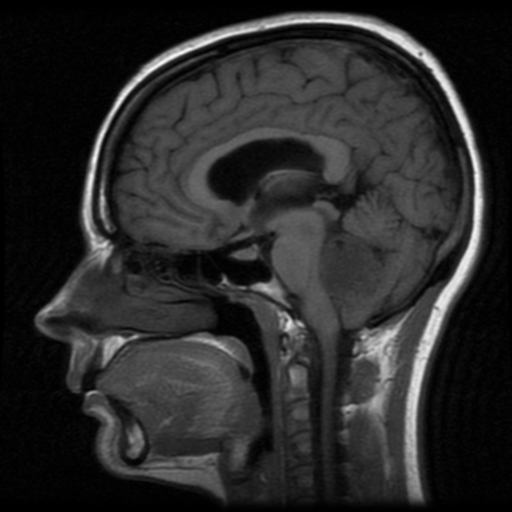

Realizamos la modificación geométrica de traslación pero ahora los valores de *tx* y *ty* no serán valores enteros si no que van a ser valores decimales. En este caso, desplazaremos 20.5 pixeles en el eje horizontal (x) y 15.5 pixeles en el eje vertical (y).

In [ ]:
# TRASLACION CON DECIMALES X = 20.5 y Y = 15.5
# tx = derecha/izq, ty = abajo/arriba
tx2 = 20.5
ty2 = 15.5

M2_traslacion = np.float32([[1, 0, tx2], [0, 1, ty2]]) # matriz de traslacion
imagen_traslaciondec = cv2.warpAffine(RMcerebral, M2_traslacion, (ancho, alto), flags=cv2.INTER_LINEAR)

Como ya se explicó anteriormente, se utiliza la *“Matriz de traslación”* usa valores unitarios en la diagonal para mantener la escala de la imagen y permitir únicamente el desplazamiento en los ejes *x* y *y* (tx, ty). Por otro lado, la función **cv2.warpAffine** aplica esta transformación geométrica usando dicha matriz, mientras que las dimensiones obtenidas con **.shape** se emplean para definir el tamaño de salida, asegurando que la imagen transformada conserve las mismas dimensiones que la original.

El parámetro flags define el método de interpolación empleada en la transformación de la imagen, en este caso, la interpolación lineal (***cv2.INTER_LINEAR***) se calcula valores de nuevos píxeles cuando los píxeles no coinciden exactamente con posiciones enteras, como al trabajar con traslaciones con decimales.

Ahora, visualizando la imagen con modificación geométrica de traslación con decimales:

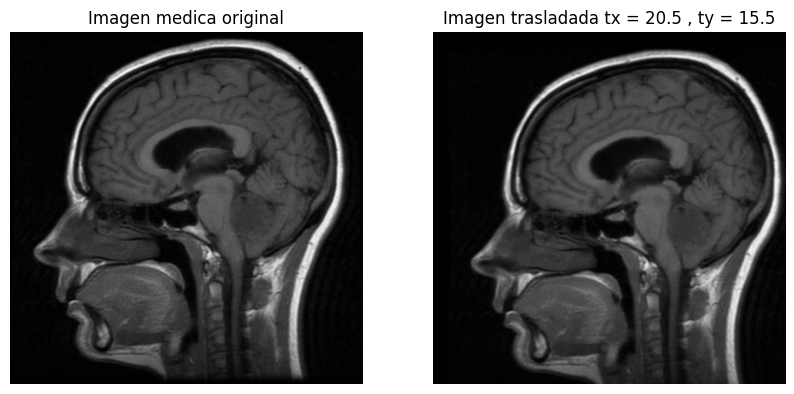

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.imshow(RMcerebral, cmap="gray")
plt.title("Imagen medica original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_traslaciondec, cmap="gray")
plt.title("Imagen trasladada tx = 20.5 , ty = 15.5")
plt.axis("off")

plt.show()

### **EJERCICIO 3.** ***Traslación + Rotación.***

Para este ejercicio se seleccionó una imagen médica correspondiente a un corte coronal de una angiografía de la aorta abdominal, la cual se encuentra en escala de grises, facilitando el análisis de las estructuras internas sin la influencia de información de color.

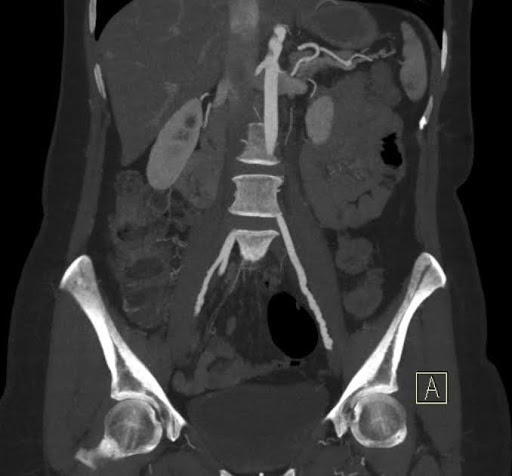



Para la elaboración del código, se emplearon nuevamente las librerías OpenCV, NumPy y Matplotlib, las cuales permiten la lectura, procesamiento y visualización de la imagen de manera eficiente dentro del entorno de Python.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Posteriormente, se realizó la carga de la imagen utilizando la función **cv2.imread()**, especificando el parámetro **cv2.IMREAD_GRAYSCALE** para asegurar que la imagen se trabaje en un solo canal de intensidad. Asimismo, se utilizó la función .shape para obtener las dimensiones de la imagen, es decir, su alto y ancho, valores que serán necesarios para aplicar correctamente las transformaciones geométricas sin alterar el tamaño original.


In [ ]:
imagen = cv2.imread(r"fibromuscular.jpg", cv2.IMREAD_GRAYSCALE)

alto, ancho = imagen.shape


A continuación, se aplicó una transformación geométrica de traslación, en la cual se desplazaron los píxeles de la imagen 50 unidades en el eje horizontal (x) y 30 unidades en el eje vertical (y). Para ello, se definió una matriz de traslación, la cual mantiene valores unitarios en la diagonal principal para conservar la escala de la imagen y únicamente modificar su posición mediante los parámetros tx y ty


In [ ]:
#definicion de la traslacion
tx, ty = 50, 30
M_translacion = np.float32([[1, 0, tx], [0, 1, ty]])

#aplicar traslación
imagen_trasladada = cv2.warpAffine(imagen, M_translacion, (ancho, alto))


La transformación se aplicó utilizando la función **cv2.warpAffine()**, la cual permite realizar transformaciones geométricas a partir de una matriz. En este caso, se utilizaron las dimensiones originales de la imagen para asegurar que la imagen trasladada conserve su tamaño sin sufrir deformaciones.

Posteriormente, se implementó una transformación de rotación, definiendo un ángulo de 50 grados alrededor del centro de la imagen. Para ello, se calculó el centro utilizando las dimensiones obtenidas previamente, y se utilizó la función **cv2.getRotationMatrix2D()**, la cual genera la matriz de rotación considerando el ángulo y un factor de escala igual a 1, lo que indica que no habrá cambio en el tamaño de la imagen.


In [ ]:

#definicion de la rotacion
angulo = 50
centro = (ancho // 2, alto // 2)
escala = 1.0

M_rotacion = cv2.getRotationMatrix2D(centro, angulo, escala)

#aplicar la rotacion
imagen_final = cv2.warpAffine(imagen_trasladada, M_rotacion, (ancho, alto))


La rotación se aplicó sobre la imagen previamente trasladada, nuevamente mediante la función **cv2.warpAffine()**, lo que permite observar el efecto combinado de ambas transformaciones geométricas.

Finalmente, se realizó la visualización de los resultados utilizando Matplotlib, mostrando en una misma figura la imagen original, la imagen trasladada y la imagen con ambas transformaciones aplicadas.


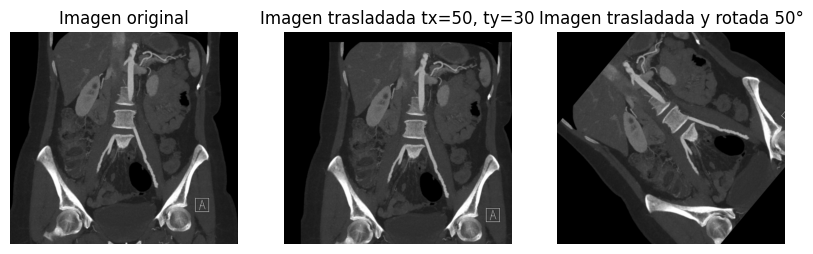

In [ ]:

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen trasladada tx=50, ty=30")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_final, cmap="gray")
plt.title("Imagen trasladada y rotada 50°")
plt.axis("off")

plt.show()

### **EJERCICIO 4.** ***Traslación + Rotación + Escalado.***

Para este ejercicio se utilizó la misma imagen médica empleada en el *Ejercicio 3*, correspondiente a un corte coronal de angiografía en escala de grises.

Inicialmente, se cargó la imagen y se obtuvieron sus dimensiones mediante la función .shape, lo cual permitió conocer el alto y ancho de la imagen. Estos valores son necesarios para aplicar correctamente las transformaciones geométricas sin modificar el tamaño original de la imagen.

Posteriormente, se aplicó una transformación geométrica de traslación, desplazando la imagen 50 píxeles en el eje horizontal (x) y 30 píxeles en el eje vertical (y). Para ello, se definió la matriz de traslación con valores unitarios en la diagonal, lo que permite conservar la escala de la imagen y modificar únicamente su posición dentro del plano.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread(r"fibromuscular.jpg", cv2.IMREAD_GRAYSCALE)

alto, ancho = imagen.shape


tx, ty = 50, 30
M_translacion = np.float32([[1, 0, tx], [0, 1, ty]])
imagen_trasladada = cv2.warpAffine(imagen, M_translacion, (ancho, alto))


Una vez obtenida la imagen trasladada, se procedió a aplicar una transformación combinada de rotación y escalado. Se definió un ángulo de rotación de 50 grados con respecto al centro de la imagen, el cual se calculó a partir de sus dimensiones. Además, se utilizaron dos factores de escala distintos: uno de 0.8, que reduce el tamaño de la imagen, y otro de 1.5, que la amplía.

In [ ]:
angulo = 50
escala1 = 0.8
escala2 = 1.5
centro = (ancho // 2, alto // 2)

M_rotacion_escala1 = cv2.getRotationMatrix2D(centro, angulo, escala1)
M_rotacion_escala2 = cv2.getRotationMatrix2D(centro, angulo, escala2)

imagen_final1 = cv2.warpAffine(imagen_trasladada, M_rotacion_escala1, (ancho, alto))
imagen_final2 = cv2.warpAffine(imagen_trasladada, M_rotacion_escala2, (ancho, alto))


Estas transformaciones se aplicaron sobre la imagen previamente trasladada, obteniendo dos resultados distintos. En el primer caso, la imagen presenta una reducción de tamaño junto con la rotación, lo que permite observar una mayor porción de la imagen. En el segundo caso, la imagen se amplía, permitiendo apreciar con mayor detalle las estructuras.
Finalmente, se visualizaron los resultados mostrando en una misma figura la imagen original, la imagen trasladada y las imágenes con rotación y escalado aplicados.


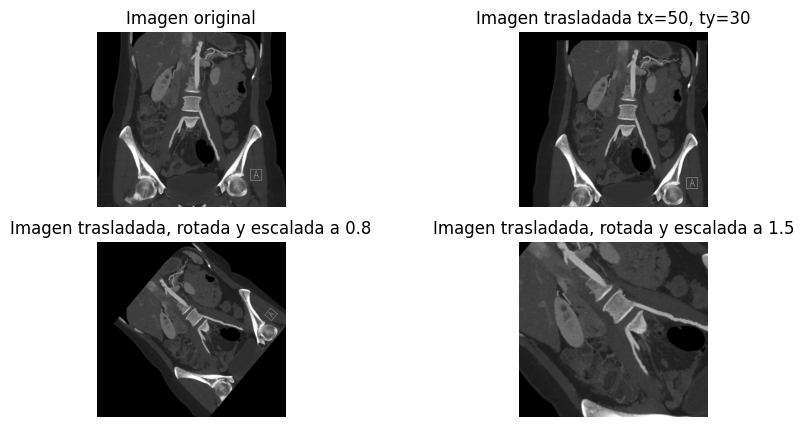

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen trasladada tx=50, ty=30")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(imagen_final1, cmap="gray")
plt.title("Imagen trasladada, rotada y escalada a 0.8")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(imagen_final2, cmap="gray")
plt.title("Imagen trasladada, rotada y escalada a 1.5")
plt.axis("off")
plt.show()

### **EJERCICIO 5.** ***Transformación Afín y Radial.***

Para este ejercicio se utilizó la misma imagen médica empleada en el *Ejercicio 3*.
Se aplicó una transformación afín, la cual permite modificar la geometría de la imagen mediante operaciones como traslación, rotación, escalado y deformación. Para ello, se definieron tres puntos originales dentro de la imagen y sus correspondientes puntos transformados. Estos puntos sirven como referencia para calcular la nueva disposición de los píxeles.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread(r"fibromuscular.jpg", cv2.IMREAD_GRAYSCALE)

pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

A partir de estos puntos, se obtuvo la matriz de transformación afín utilizando la función correspondiente, la cual permite mapear los puntos originales hacia sus nuevas posiciones. Esta matriz se aplica posteriormente a toda la imagen, generando una transformación que puede incluir inclinación o deformación de la estructura original, sin perder la relación entre líneas y paralelismo.

In [ ]:
M = cv2.getAffineTransform(pts1, pts2)

filas, columnas = imagen.shape
imagen_transformada = cv2.warpAffine(imagen, M, (columnas, filas))

La transformación se ejecutó utilizando una función que toma en cuenta las dimensiones originales de la imagen para evitar cambios en su tamaño. Como resultado, se obtuvo una imagen en la que las estructuras presentan una modificación en su forma y orientación, lo que permite analizar cómo este tipo de transformación afecta la representación espacial de los elementos.
Posteriormente, se implementó una corrección de distorsión radial, la cual es común en sistemas de adquisición de imágenes debido a las características de los lentes. Para ello, se definió una matriz intrínseca de la cámara junto con coeficientes de distorsión radial, los cuales modelan la deformación que sufren los píxeles al alejarse del centro de la imagen.


In [ ]:
K = np.array([[1000, 0, 640], [0, 1000, 360], [0, 0, 1]])
dist_coef = np.array([-0.2, 0.05, 0, 0, 0])

A partir de estos parámetros, se generó una nueva matriz optimizada que permite corregir la distorsión presente en la imagen. Posteriormente, se aplicó esta corrección, obteniendo una imagen en la que las líneas y estructuras presentan una forma más natural y menos deformada.

In [ ]:
h, w = imagen.shape[:2]
new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist_coef, (w, h), 1, (w, h))
imagen_corregida = cv2.undistort(imagen, K, dist_coef, None, new_K)

Finalmente, se visualizaron los resultados mostrando la imagen original junto con las imágenes transformadas, lo que permite comparar directamente los efectos de la transformación afín y la corrección de distorsión radial en la representación de la imagen.

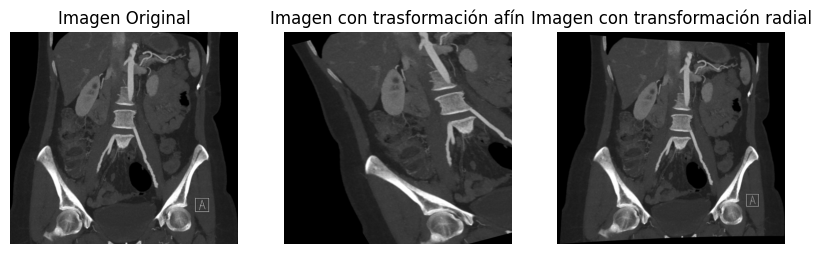

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen_transformada, cmap="gray")
plt.title("Imagen con trasformación afín")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_corregida, cmap="gray")
plt.title("Imagen con transformación radial")
plt.axis("off")

plt.show()